1. IMPORTAR LIBRERÍAS


In [ ]:
pip install ultralytics roboflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 61.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [ ]:
from ultralytics import YOLO
from roboflow import Roboflow
import pandas as pd
import matplotlib.pyplot as plt
import os
import yaml
from collections import defaultdict



Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


2. DESCARGAR DATASET DESDE ROBOFLOW (YOLOv8)

In [ ]:
rf = Roboflow(api_key="eA9HRxhb3zw8Vxj1xEft")

project = rf.workspace("tesis-kmw54").project("segmentacion-deteccion-de-defectos-del-grano")
version = project.version(1)


dataset = version.download("yolov8")

base_path = dataset.location

splits = ["train", "valid", "test"]

# cargar nombres de clases
with open(os.path.join(base_path, "data.yaml"), "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

for split in splits:

    labels_path = os.path.join(base_path, split, "labels")

    if not os.path.exists(labels_path):
        continue

    class_counts = defaultdict(int)

    for file in os.listdir(labels_path):
        if file.endswith(".txt"):
            with open(os.path.join(labels_path, file)) as f:
                for line in f:
                    class_id = int(line.split()[0])
                    class_counts[class_id] += 1

    print(f"\n===== {split.upper()} =====")

    for class_id, count in class_counts.items():
        print(f"{class_names[class_id]}: {count}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Segmentacion-Detección-de-defectos-del-grano--1 in yolov8:: 100%|██████████| 987/987 [00:00<00:00, 1317.28it/s]



===== TRAIN =====
grano_negro: 191
agrio_parcial: 196
normal: 213
cereza_seca: 228
broca_leve_severa: 171
cortado: 291
negro_parcial: 214
concha: 192
por_hongo: 241

===== VALID =====
cereza_seca: 65
negro_parcial: 57
grano_negro: 47
agrio_parcial: 61
concha: 64
cortado: 65
broca_leve_severa: 48
normal: 26
por_hongo: 41

===== TEST =====
normal: 57
grano_negro: 65
cereza_seca: 76
concha: 46
agrio_parcial: 53
negro_parcial: 102
cortado: 94
por_hongo: 59
broca_leve_severa: 87


4. RUTA DEL DATASET

In [ ]:
DATA_YAML = f"{dataset.location}/data.yaml"
print(DATA_YAML)


/content/Segmentacion-Detección-de-defectos-del-grano--1/data.yaml


5. CARGAR MODELO PREENTRENADO (TRANSFER LEARNING)

In [ ]:
from ultralytics import YOLO
model = YOLO("yolov8x-seg.pt")


6. ENTRENAMIENTO (CON VALIDACIÓN AUTOMÁTICA)

In [ ]:
model.train(
    data=DATA_YAML,
    epochs=150,
    imgsz=640,
    batch=16,
    lr0=0.001,
    weight_decay=0.0005,
    freeze=10,

    # Data augmentation (solo entrenamiento)
    mosaic=1.0,
    mixup=0.2,
    fliplr=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5
)


Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Segmentacion-Detección-de-defectos-del-grano--1/data.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8x-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimize

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x792b598a92e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,   

7. TEST FINAL (CONJUNTO DE TEST)

In [ ]:
metrics = model.val(
    data=DATA_YAML,
    split="test",
    batch=1,
    imgsz=640,
    workers=0,
    device=0
)


Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8x-seg summary (fused): 126 layers, 71,729,323 parameters, 0 gradients, 328.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 97.6±34.4 MB/s, size: 472.5 KB)
val: Scanning /content/Segmentacion-Detección-de-defectos-del-grano--1/test/labels... 99 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 99/99 340.3it/s 0.3s
val: New cache created: /content/Segmentacion-Detección-de-defectos-del-grano--1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 99/99 6.1it/s 16.1s
                   all         99        639      0.912      0.875      0.925      0.919      0.914      0.876      0.925      0.834
         agrio_parcial         10         53      0.886      0.733       0.89       0.89      0.886      0.733       0.89      0.802
     broca_leve_severa         15         87 

8. PREDICCIÓN Y VISUALIZACIÓN DE IMÁGENES (TEST)

In [ ]:
import os

folder = f"{dataset.location}/test/images"

for img in os.listdir(folder):
    model.predict(
        source=os.path.join(folder, img),
        conf=0.25,
        save=True,
        imgsz=512
    )


image 1/99 /content/Segmentacion-Detección-de-defectos-del-grano--1/test/images/IMG_4743_JPG.rf.6523a88e07fb5db0371223a4d40f1090.jpg: 352x512 1 broca_leve_severa, 7 normals, 60.9ms
image 2/99 /content/Segmentacion-Detección-de-defectos-del-grano--1/test/images/IMG_4766_JPG.rf.eae65db1a92925e0be15a3b30a3504ce.jpg: 352x512 4 agrio_parcials, 1 cortado, 32.6ms
image 3/99 /content/Segmentacion-Detección-de-defectos-del-grano--1/test/images/IMG_4767_JPG.rf.1c981a0468419ab9d3856a7fbffa88b0.jpg: 352x512 3 agrio_parcials, 2 broca_leve_severas, 1 cortado, 5 normals, 32.5ms
image 4/99 /content/Segmentacion-Detección-de-defectos-del-grano--1/test/images/IMG_4844_JPG.rf.4dd65236fb29bcf904929af9f81d3b96.jpg: 352x512 2 agrio_parcials, 7 broca_leve_severas, 8 normals, 32.5ms
image 5/99 /content/Segmentacion-Detección-de-defectos-del-grano--1/test/images/IMG_4846_JPG.rf.d2bc115a327b2ea18a645ee582084884.jpg: 352x512 1 grano_negro, 7 normals, 26.9ms
image 6/99 /content/Segmentacion-Detección-de-defectos

In [ ]:
from IPython.display import Image, display
import glob

for img in glob.glob("/content/runs/segment/predict/*.jpg")[:5]:
    display(Image(filename=img))


9. OBTENER PRECISIÓN FINAL EN PORCENTAJE

In [ ]:
import pandas as pd

results_csv = "/content/runs/segment/train/results.csv"
df = pd.read_csv(results_csv)

final_precision = df["metrics/precision(B)"].iloc[-1]
precision_percent = final_precision * 100

print(f"✅ Porcentaje de Precisión alcanzado: {precision_percent:.2f}%")


✅ Porcentaje de Precisión alcanzado: 91.26%


In [ ]:
import pandas as pd

results_csv = "/content/runs/segment/train/results.csv"
df = pd.read_csv(results_csv)

# Precisión
final_precision = df["metrics/precision(B)"].iloc[-1]
precision_percent = final_precision * 100

# mAP@0.5
map50 = df["metrics/mAP50(B)"].iloc[-1]
map50_percent = map50 * 100

# mAP@0.5:0.95
map5095 = df["metrics/mAP50-95(B)"].iloc[-1]
map5095_percent = map5095 * 100

print(f"✅ Precisión: {precision_percent:.2f}%")
print(f"📊 mAP@0.5: {map50_percent:.2f}%")
print(f"📊 mAP@0.5:0.95: {map5095_percent:.2f}%")

✅ Precisión: 91.26%
📊 mAP@0.5: 91.16%
📊 mAP@0.5:0.95: 90.98%


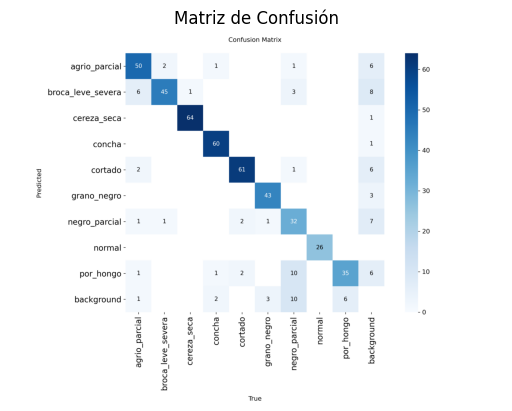

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

conf_matrix_path = "/content/runs/segment/train/confusion_matrix.png"

img = Image.open(conf_matrix_path)
plt.imshow(img)
plt.axis("off")
plt.title("Matriz de Confusión")
plt.show()

In [ ]:
print(results.box.mr)

NameError: name 'results' is not defined

In [ ]:
from ultralytics import YOLO

model = YOLO('runs/detect/train/weights/best.pt')
model.export(format='tflite')